In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
import plotly.express as px



# Analysis on eigenvalues : 
- What weight ?
    - by layer : matrix is not squared -> svd
    - by gate : same -> svd
    - by weight by gate (recurrent/input)-> eigenvals
- What analysis ?
    - magnitude of leading eigenvals through time (in terms of real and imaginary part)

## Analysis layer 1


In [2]:
layer1 = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/weights/layer_1_gate_weights_fc.pt')

In [3]:
layer1.shape

torch.Size([41, 1, 4, 650, 1300])

In [4]:
num_checkpoints = layer1.shape[0]
num_layers = layer1.shape[1]  # Should be 1
num_gates = layer1.shape[2]  # Should be 4
hidden_size = layer1.shape[3]
combined_size = layer1.shape[4]
input_size = combined_size - hidden_size

In [5]:
epochs = np.arange(1, num_checkpoints + 1)


In [6]:
layer_1_sv_whole = []
for checkpoint_idx in range(num_checkpoints):
    # Extract weights for all gates at the current checkpoint
    all_gates_weights = layer1[checkpoint_idx, 0]  # Shape: (4, hidden_size, input_size + hidden_size)
    whole_layer_weight = all_gates_weights.reshape(4 * hidden_size, combined_size).numpy()
    sv_whole = np.linalg.svd(whole_layer_weight, compute_uv=False)
    layer_1_sv_whole.append(sv_whole)


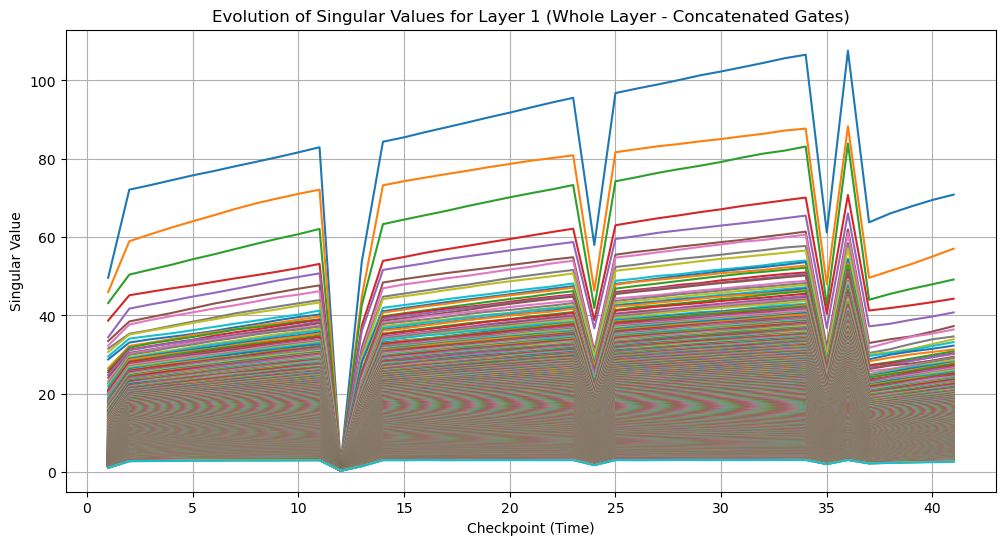

In [7]:
plt.figure(figsize=(12, 6))
for i in range(layer_1_sv_whole[0].shape[0]):
    plt.plot(epochs, [s[i] for s in layer_1_sv_whole], label=f'Singular Value {i+1}')
plt.title('Evolution of Singular Values for Layer 1 (Whole Layer - Concatenated Gates)')
plt.xlabel('Checkpoint (Time)')
plt.ylabel('Singular Value')
#plt.legend(fontsize='small')
plt.grid(True)
plt.show()

In [8]:
layer_1_sv_gates = [[] for _ in range(num_gates)]
gate_names = ["Forget Gate", "Input Gate", "Cell State Gate", "Output Gate"]
epochs = np.arange(1, num_checkpoints + 1)

for checkpoint_idx in range(num_checkpoints):
    for gate_idx in range(num_gates):
        # Extract the weight matrix for the current gate at the current checkpoint
        gate_weight = layer1[checkpoint_idx, 0, gate_idx].numpy()  # Shape: (hidden_size, combined_size)
        singular_values_gate = np.linalg.svd(gate_weight, compute_uv=False)
        layer_1_sv_gates[gate_idx].append(singular_values_gate)

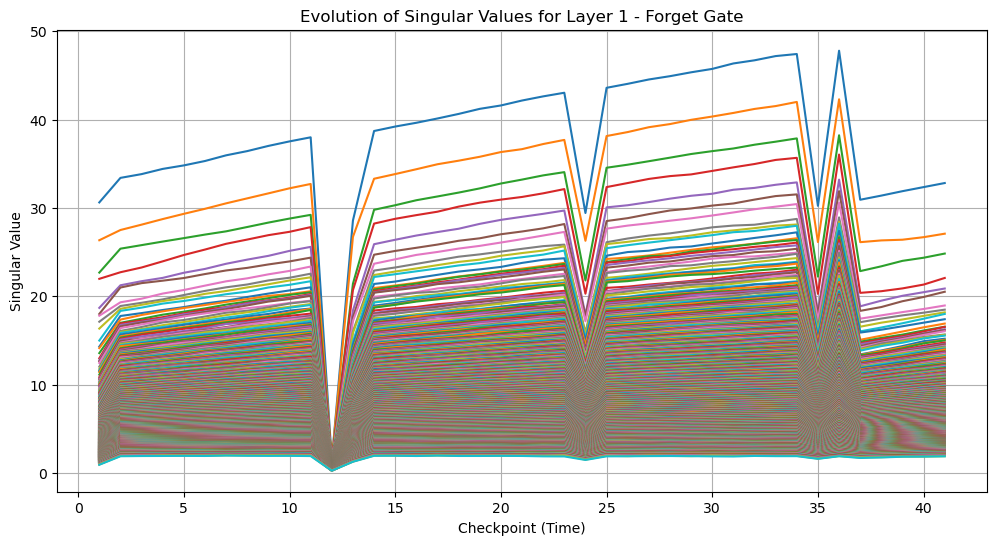

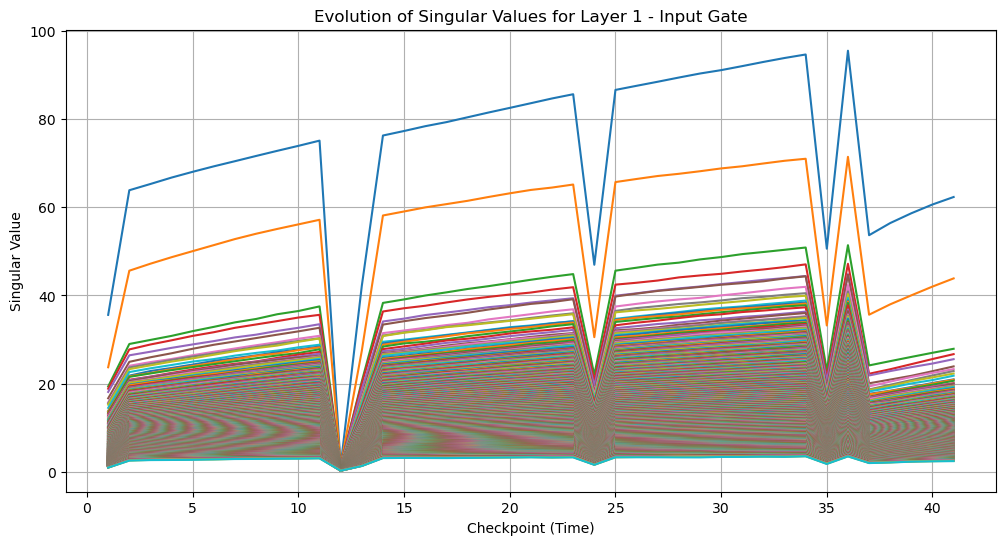

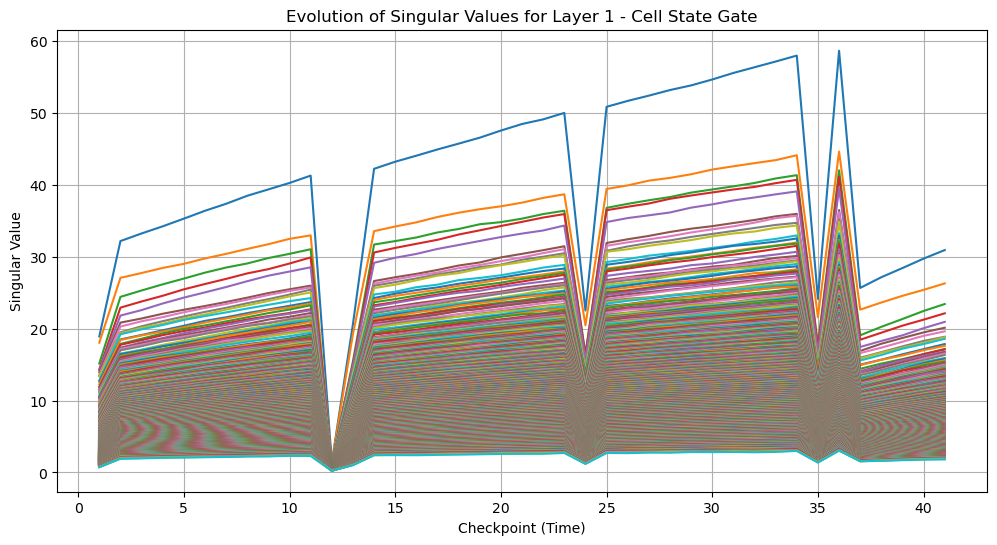

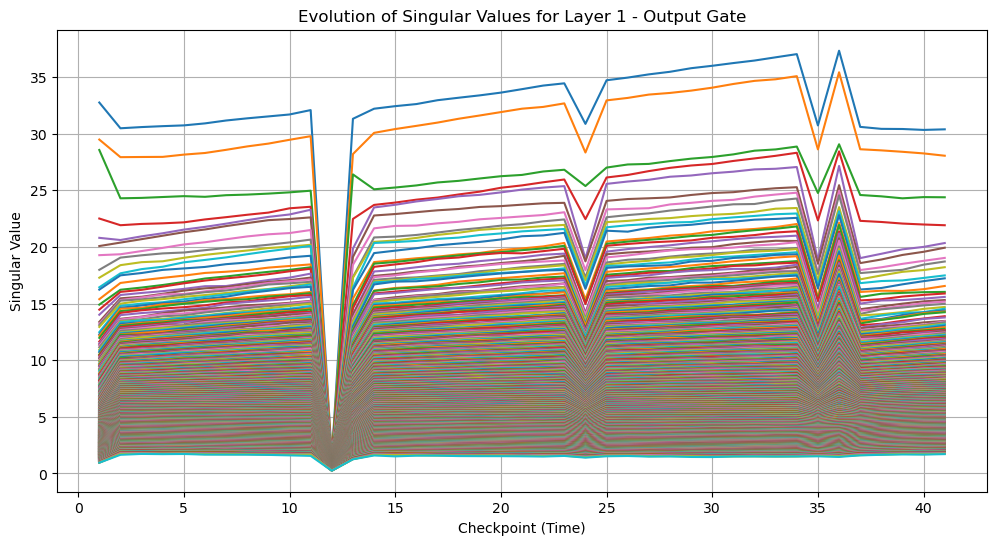

In [9]:
for i, gate_singular_values in enumerate(layer_1_sv_gates):
    plt.figure(figsize=(12, 6))
    for j in range(gate_singular_values[0].shape[0]):
        plt.plot(epochs, [s[j] for s in gate_singular_values], label=f'Singular Value {j+1}')
    plt.title(f'Evolution of Singular Values for Layer 1 - {gate_names[i]}')
    plt.xlabel('Checkpoint (Time)')
    plt.ylabel('Singular Value')
    #plt.legend(fontsize='small')
    plt.grid(True)
    plt.show()

In [52]:
print(layer1.shape)

torch.Size([22, 1, 4, 650, 1300])


In [53]:
layer1[0,0,:,:,:hidden_size].shape

torch.Size([4, 650, 650])

In [10]:
layer_1_eig_rec_gates = [[] for _ in range(num_gates)]
gate_names = ["Forget Gate", "Input Gate", "Cell State Gate", "Output Gate"]
epochs = np.arange(1, num_checkpoints + 1)

for checkpoint_idx in range(num_checkpoints):
    for gate_idx in range(num_gates):
        # Extract the weight matrix for the current gate at the current checkpoint
        recurrent_gate_weight = layer1[checkpoint_idx, 0, gate_idx, :, :hidden_size].numpy()  # Shape: (hidden_size, combined_size)
        eig_rec_gate = np.linalg.eigvals(recurrent_gate_weight)
        layer_1_eig_rec_gates[gate_idx].append(eig_rec_gate)

In [12]:
def get_leading_eigenvals_tt(num_top_eigenvalues, nature, weights):
    eigenvals = {'forget':[], 'input':[], 'cell':[], 'output':[]}
    gate_names = ['forget', 'input', 'cell', 'output']
    for gate in range(len(weights)):
        gate_dynamics = []
        for epoch in range(len(weights[0])):

            eigenval_magnitude = np.abs(weights[gate][epoch].real)
            sorting = np.argsort(eigenval_magnitude, axis=0)[::-1]
            top_indices = sorting[:num_top_eigenvalues]
            if nature == 'real':
                top_eigenvals = weights[gate][epoch].real[top_indices]
            elif nature == 'imag':
                top_eigenvals = weights[gate][epoch].imag[top_indices]
            else:
                raise ValueError("The 'nature' argument must be either 'real' or 'imag'.")


            gate_dynamics.append(top_eigenvals)
        eigenvals[gate_names[gate]]= gate_dynamics
    return eigenvals

In [13]:
def plot_eigenval_tt(num_top_eigenvalues, eigenvals_tt, nature):
    
    epochs = range(len(eigenvals_tt['forget']))

    plt.figure(figsize=(10, 6))
    for gate_name in gate_names:
        
        for i in range(num_top_eigenvalues):
            eigenvalue_trajectory = [eigenvals_tt[gate_name][epoch][i] for epoch in epochs]
            plt.plot(epochs, eigenvalue_trajectory, label=gate_name)

    plt.xlabel("Epoch")
    plt.ylabel(f"Real Eigenvalue (Rank {i+1})")
    if nature == 'real':
        plt.title(f"Trajectory of gates(real eigenvals)")
    elif nature == 'imag':
        plt.title(f"Trajectory of gates(complex eigenvals)")
    plt.legend()
    plt.grid(True)
    plt.show()  

In [14]:
import numpy as np
import matplotlib.pyplot as plt

gate_names = ['forget', 'input', 'cell', 'output']

def get_leading_real_with_imag_tt(num_top_eigenvalues, weights):
    real_parts = {'forget':[], 'input':[], 'cell':[], 'output':[]}
    imag_parts = {'forget':[], 'input':[], 'cell':[], 'output':[]}

    for gate in range(len(weights)):
        gate_real_dynamics = []
        gate_imag_dynamics = []
        for epoch in range(len(weights[0])):
            eigenvalues = weights[gate][epoch]
            real_magnitudes = np.abs(eigenvalues.real)
            sorting = np.argsort(real_magnitudes)[::-1]
            top_indices = sorting[:num_top_eigenvalues]
            top_real = eigenvalues.real[top_indices]
            top_imag = eigenvalues.imag[top_indices]

            gate_real_dynamics.append(top_real)
            gate_imag_dynamics.append(top_imag)

        real_parts[gate_names[gate]] = gate_real_dynamics
        imag_parts[gate_names[gate]] = gate_imag_dynamics

    return real_parts, imag_parts


def plot_real_imag_tt(num_top_eigenvalues, real_parts, imag_parts):
    epochs = range(len(real_parts['forget']))

    for i in range(num_top_eigenvalues):
        plt.figure(figsize=(14, 5))

        # Plot real parts
        plt.subplot(1, 2, 1)
        for gate_name in gate_names:
            trajectory = [real_parts[gate_name][epoch][i] for epoch in epochs]
            plt.plot(epochs, trajectory, label=gate_name)
        plt.xlabel("Epoch")
        plt.ylabel(f"Real Part (Rank {i+1})")
        plt.title("Leading Real Parts of Eigenvalues")
        plt.grid(True)
        plt.legend()

        # Plot imaginary parts of the *same* eigenvalues
        plt.subplot(1, 2, 2)
        for gate_name in gate_names:
            trajectory = [imag_parts[gate_name][epoch][i] for epoch in epochs]
            plt.plot(epochs, trajectory, label=gate_name)
        plt.xlabel("Epoch")
        plt.ylabel(f"Imaginary Part (Rank {i+1})")
        plt.title("Imaginary Part of Leading Real Eigenvalues")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()


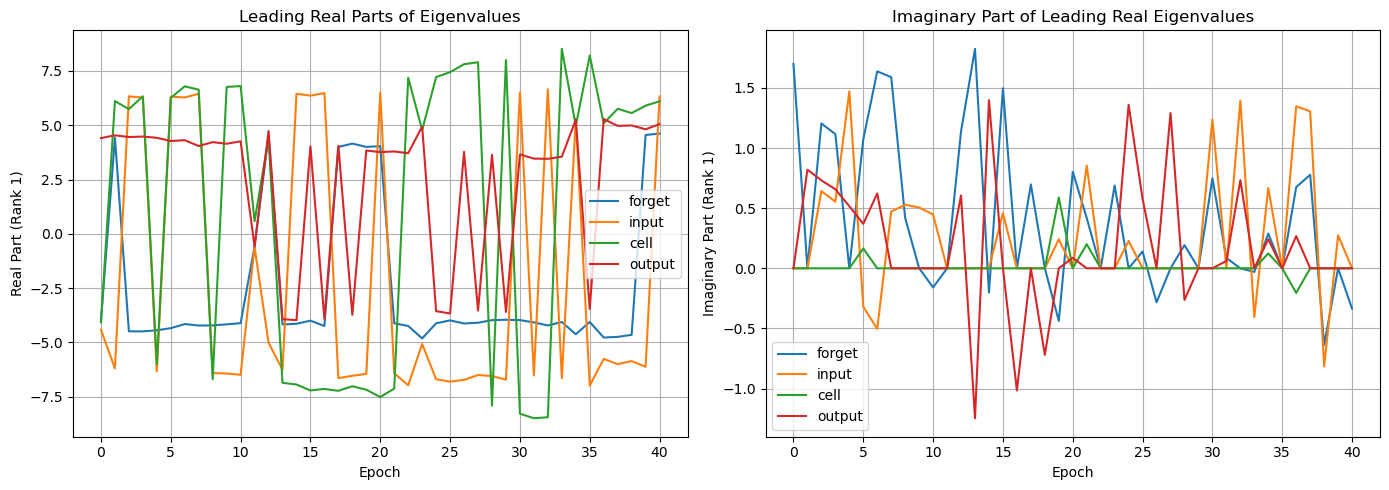

In [15]:
# re = get_leading_eigenvals_tt(1, 'real', layer_1_eig_rec_gates)
# plot_eigenval_tt(1, re, 'real')
# imag = get_leading_eigenvals_tt(1, 'imag', layer_1_eig_rec_gates)
# plot_eigenval_tt(1, imag, 'imag')
r,i= get_leading_real_with_imag_tt(1,layer_1_eig_rec_gates)
plot_real_imag_tt(1,r,i)

In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_adrian_diagram(real_parts, imag_parts, num_top_eigenvalues):
    num_epochs = len(real_parts['forget'])
    cmap = cm.get_cmap('plasma', num_epochs)
    colors = [cmap(i) for i in range(num_epochs)]
    
    for i in range(num_top_eigenvalues):
        plt.figure(figsize=(12, 4))
        for gate_idx, gate_name in enumerate(gate_names):
            plt.subplot(1, 4, gate_idx + 1)
            
            real_vals = [real_parts[gate_name][epoch][i] for epoch in range(num_epochs)]
            imag_vals = [imag_parts[gate_name][epoch][i] for epoch in range(num_epochs)]
            
            for t in range(1, num_epochs):
                plt.plot(real_vals[t-1:t+1], imag_vals[t-1:t+1], color=colors[t], linewidth=2)
            
            plt.scatter(real_vals[0], imag_vals[0], color='green', label='Start', zorder=5)
            plt.scatter(real_vals[-1], imag_vals[-1], color='red', label='End', zorder=5)
            plt.axhline(0, color='gray', linewidth=0.5)
            plt.axvline(0, color='gray', linewidth=0.5)
            plt.title(f"{gate_name.capitalize()} Gate (Rank {i+1})")
            plt.xlabel("Re(λ)")
            plt.ylabel("Im(λ)")
            plt.grid(True)
            plt.legend()
        
        plt.suptitle(f"Adrian Diagram for Top-{i+1} Eigenvalue Trajectories", fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


/tmp/ipykernel_474411/3448391538.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma', num_epochs)


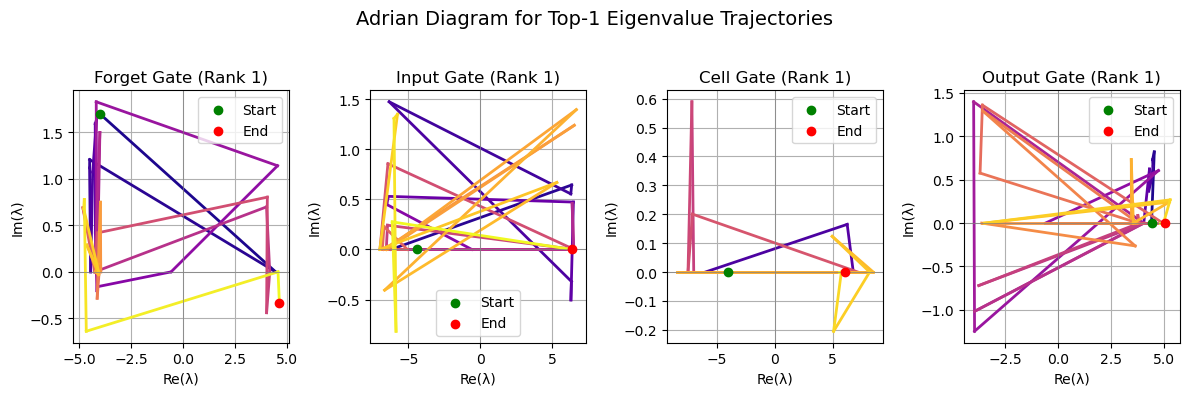

In [17]:
real_parts, imag_parts = get_leading_real_with_imag_tt(num_top_eigenvalues=1, weights=layer_1_eig_rec_gates)
plot_adrian_diagram(real_parts, imag_parts, num_top_eigenvalues=1)


In [156]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

def plot_3d_adrian_diagram(real_parts, imag_parts, num_top_eigenvalues):
    num_epochs = len(real_parts['forget'])
    cmap = cm.get_cmap('plasma', num_epochs)  # Choose your colormap
    colors = [cmap(i) for i in range(num_epochs)]

    # Create a 3D plot
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Loop over top eigenvalues
    for i in range(num_top_eigenvalues):
        # Loop over each gate and plot its trajectory
        for gate_idx, gate_name in enumerate(gate_names):
            real_vals = [real_parts[gate_name][epoch][i] for epoch in range(num_epochs)]
            imag_vals = [imag_parts[gate_name][epoch][i] for epoch in range(num_epochs)]
            
            # Plot the trajectory in 3D (Re(λ), Im(λ), Epoch)
            for t in range(1, num_epochs):
                ax.plot(real_vals[t-1:t+1], imag_vals[t-1:t+1], [t-1, t], color=colors[t], linewidth=2)
            
            # Scatter points for start and end
            ax.scatter(real_vals[0], imag_vals[0], 0, color='green', label='Start', zorder=5)
            ax.scatter(real_vals[-1], imag_vals[-1], num_epochs-1, color='red', label='End', zorder=5)
        
    # Add labels and titles
    ax.set_xlabel("Re(λ)")
    ax.set_ylabel("Im(λ)")
    ax.set_zlabel("Epoch")
    ax.set_title(f"3D Adrian Diagram for Top-{i+1} Eigenvalue Trajectories")
    ax.grid(True)
    #ax.legend()

    plt.show()


/tmp/ipykernel_3253037/2549936553.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



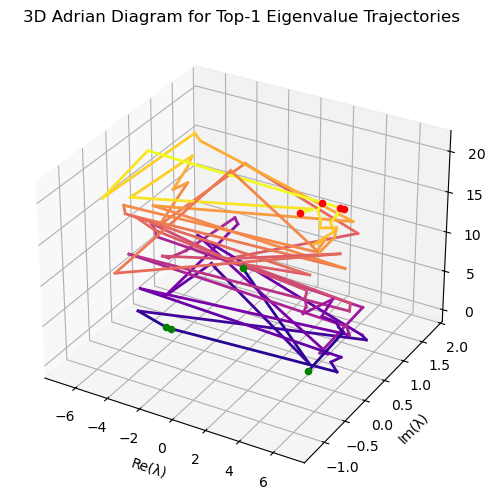

In [157]:
plot_3d_adrian_diagram(real_parts, imag_parts, num_top_eigenvalues=1)


## Rank analysis

In [ ]:
layer_1_rank_rec_gates = [[] for _ in range(num_gates)]
gate_names = ["Forget Gate", "Input Gate", "Cell State Gate", "Output Gate"]
epochs = np.arange(1, num_checkpoints + 1)

for checkpoint_idx in range(num_checkpoints):
    for gate_idx in range(num_gates):
        # Extract the weight matrix for the current gate at the current checkpoint
        recurrent_gate_weight = layer1[checkpoint_idx, 0, gate_idx, :, :hidden_size].numpy()  # Shape: (hidden_size, combined_size)
        rank_rec_gate = np.linalg.matrix_rank(recurrent_gate_weight)
        layer_1_rank_rec_gates[gate_idx].append(rank_rec_gate)    

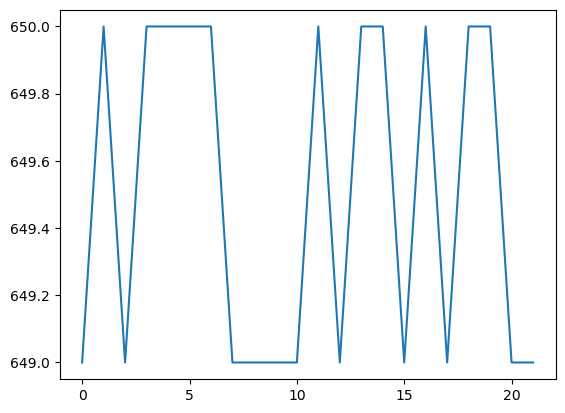

In [175]:

plt.plot(epochs, layer_1_rank_rec_gates[3])

## Analysis of eigenvalue distribution

In [176]:
def plot_eigenvalue_distribution(eigenvalues, num_epochs):
    cmap = cm.get_cmap('plasma', num_epochs)
    epochs = np.arange(num_epochs)
    
    for gate_name in eigenvalues:
        plt.figure(figsize=(12, 6))
        
        for epoch in epochs:
            eigvals = eigenvalues[gate_name][epoch]
            real_parts = np.real(eigvals)
            imag_parts = np.imag(eigvals)
            
            # Plot the histogram of eigenvalues' real and imaginary parts
            plt.hist(real_parts, bins=30, color=cmap(epoch), alpha=0.5, label=f"Epoch {epoch}")
            plt.hist(imag_parts, bins=30, color=cmap(epoch), alpha=0.5)

        plt.title(f"Eigenvalue Distribution Over Time: {gate_name.capitalize()} Gate")
        plt.xlabel("Eigenvalue Value")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True)
        plt.show()


In [190]:
import seaborn as sns

/tmp/ipykernel_3253037/209605109.py:42: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_3253037/209605109.py:42: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_3253037/209605109.py:42: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/tmp/ipykernel_3253037/209605109.py:42: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



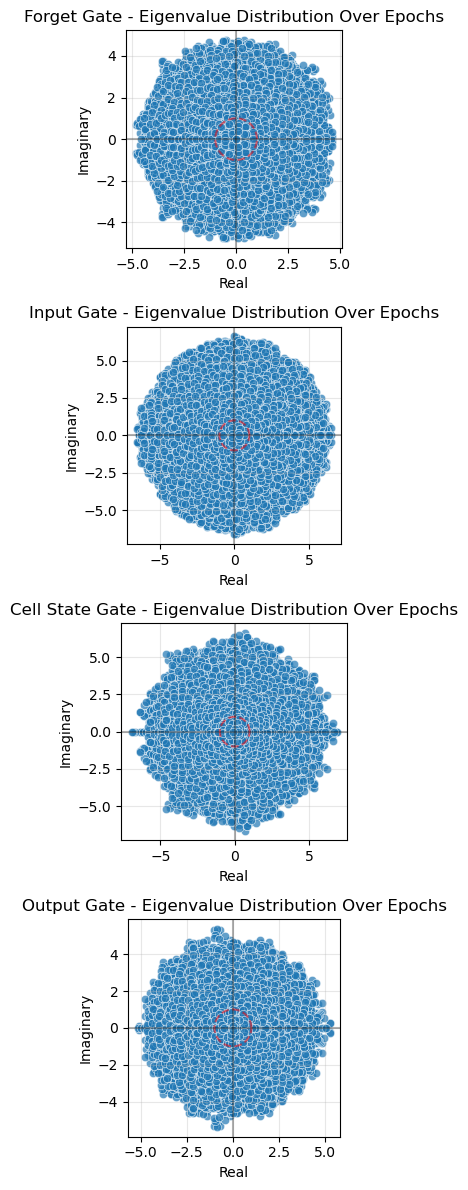

In [192]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_adrian_diagrams(eigenvalues_list, gate_names, epochs, figsize=(16, 12)):
    """
    Plot Adrian diagrams (eigenvalue distributions in complex plane) for each gate across epochs
    
    Parameters:
    - eigenvalues_list: List of lists of eigenvalues per gate across epochs
    - gate_names: List of gate names
    - epochs: Array of epoch numbers
    - figsize: Figure size
    """
    num_gates = len(eigenvalues_list)
    num_epochs = len(epochs)
    
    # Create a figure with subplots for each gate
    fig, axs = plt.subplots(num_gates, 1, figsize=figsize)
    
    for gate_idx, gate_name in enumerate(gate_names):
        # Create a dataframe for the eigenvalues of this gate across all epochs
        all_data = []
        
        for epoch_idx, epoch in enumerate(epochs):
            # Get eigenvalues for this gate at this epoch
            eig_vals = eigenvalues_list[gate_idx][epoch_idx]
            
            # Create a dataframe for this epoch's eigenvalues
            for eig in eig_vals:
                all_data.append({
                    'Real': np.real(eig),
                    'Imaginary': np.imag(eig),
                    'Epoch': f'Epoch {epoch}'
                })
        
        # Convert to dataframe
        df = pd.DataFrame(all_data)
        
        # Plot scatterplot on the complex plane
        sns.scatterplot(
            data=df,
            x='Real',
            y='Imaginary',
            #hue='Epoch',
            palette='viridis',
            alpha=0.7,
            ax=axs[gate_idx] if num_gates > 1 else axs
        )
        
        # Add a unit circle
        theta = np.linspace(0, 2*np.pi, 100)
        x, y = np.cos(theta), np.sin(theta)
        current_ax = axs[gate_idx] if num_gates > 1 else axs
        current_ax.plot(x, y, 'r--', alpha=0.5)
        
        # Set labels and title
        current_ax.set_title(f'{gate_name} - Eigenvalue Distribution Over Epochs')
        current_ax.set_xlabel('Real')
        current_ax.set_ylabel('Imaginary')
        current_ax.grid(True, alpha=0.3)
        current_ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        current_ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        
        # Set aspect ratio to be equal
        current_ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

# Now use the function with your data
fig = plot_adrian_diagrams(layer_1_eig_rec_gates, gate_names, epochs)
plt.show()

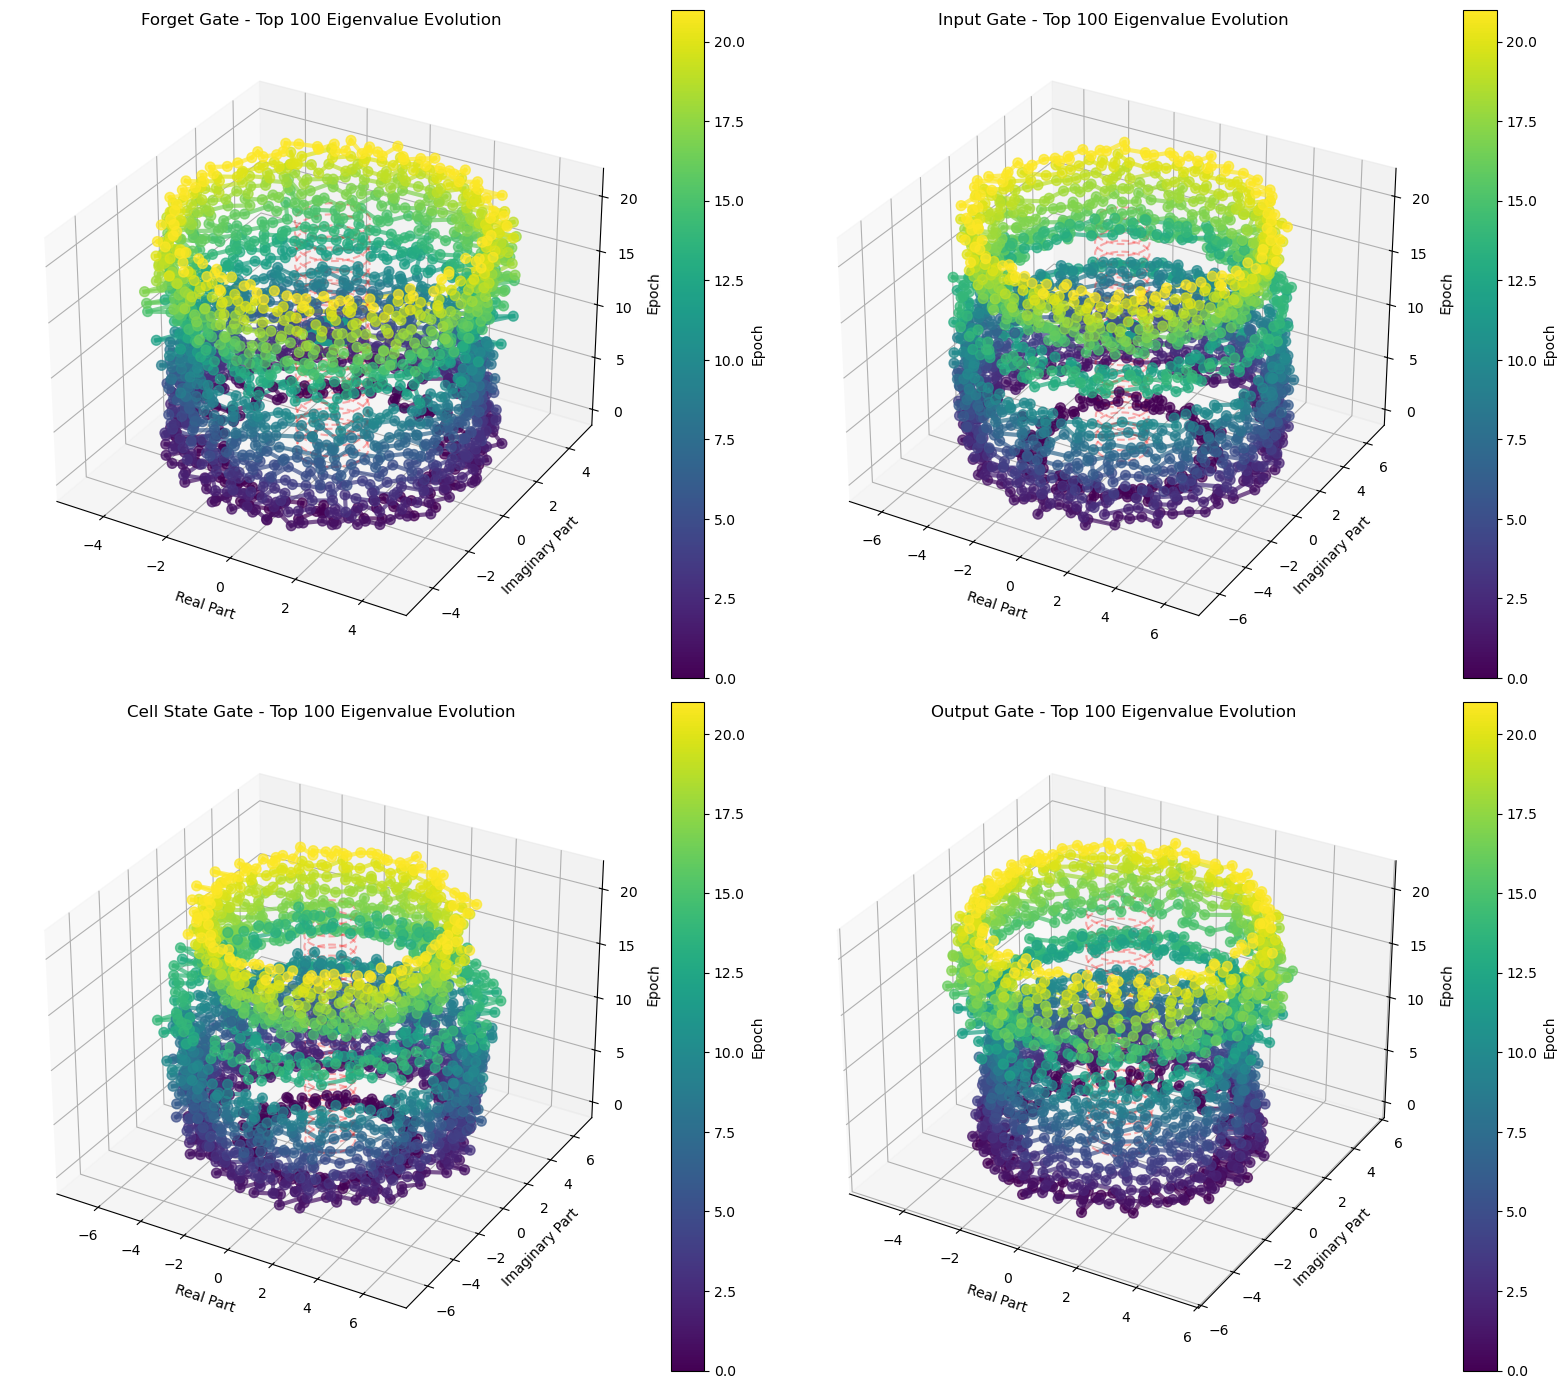

In [208]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd

def plot_3d_eigenvalue_evolution(eigenvalues_list, gate_names, epochs, figsize=(16, 14), top_n=10):
    """
    Plot 3D Adrian diagrams with time as the third dimension, showing only top_n eigenvalues
    
    Parameters:
    - eigenvalues_list: List of lists of eigenvalues per gate across epochs
    - gate_names: List of gate names
    - epochs: Array of epoch numbers
    - figsize: Figure size
    - top_n: Number of top eigenvalues to plot (selected by magnitude)
    """
    num_gates = len(eigenvalues_list)
    
    # Create a figure with 3D subplots
    fig = plt.figure(figsize=figsize)
    
    for gate_idx, gate_name in enumerate(gate_names):
        # Create a 3D subplot
        ax = fig.add_subplot(2, 2, gate_idx + 1, projection='3d')
        
        # Prepare colormap for epochs
        cmap = plt.cm.viridis
        norm = plt.Normalize(min(epochs), max(epochs))
        
        # For each epoch, plot the eigenvalues
        for epoch_idx, epoch in enumerate(epochs):
            eig_vals = eigenvalues_list[gate_idx][epoch_idx]
            
            # Select top_n eigenvalues by magnitude
            magnitudes = np.abs(eig_vals)
            top_indices = np.argsort(magnitudes)[-top_n:]  # Get indices of top_n largest magnitudes
            
            # Select only the top eigenvalues
            top_eig_vals = eig_vals[top_indices]
            
            real_parts = np.real(top_eig_vals)
            imag_parts = np.imag(top_eig_vals)
            # Create a time coordinate for all eigenvalues at this epoch
            time_coords = np.full_like(real_parts, epoch)
            
            # Plot eigenvalues as points in 3D space
            scatter = ax.scatter(
                real_parts, 
                imag_parts, 
                time_coords,
                c=[cmap(norm(epoch))] * len(top_eig_vals),
                alpha=0.7,
                s=50,  # Increase point size for better visibility
                label=f'Epoch {epoch}'
            )
            
            # Optional: Connect points between consecutive epochs with lines
            # if epoch_idx > 0:
            #     prev_eig_vals = eigenvalues_list[gate_idx][epoch_idx - 1]
            #     prev_epoch = epochs[epoch_idx - 1]
                
            #     # Select top_n eigenvalues from previous epoch
            #     prev_magnitudes = np.abs(prev_eig_vals)
            #     prev_top_indices = np.argsort(prev_magnitudes)[-top_n:]
            #     prev_top_eig_vals = prev_eig_vals[prev_top_indices]
                
            #     # Try to match eigenvalues between epochs (using nearest neighbor in complex plane)
            #     for i, curr_eig in enumerate(top_eig_vals):
            #         # Find closest eigenvalue from previous epoch
            #         distances = np.abs(prev_top_eig_vals - curr_eig)
            #         closest_idx = np.argmin(distances)
                    
            #         # Draw connection line
            #         ax.plot(
            #             [np.real(prev_top_eig_vals[closest_idx]), real_parts[i]],
            #             [np.imag(prev_top_eig_vals[closest_idx]), imag_parts[i]],
            #             [prev_epoch, epoch],
            #             color='gray', alpha=0.5
            #         )
            angles = np.angle(top_eig_vals)
            sorted_indices = np.argsort(angles)
            
            for i in range(len(sorted_indices)):
                idx1 = sorted_indices[i]
                idx2 = sorted_indices[(i + 1) % len(sorted_indices)]  # Wrap around to connect the last with the first
                
                ax.plot(
                    [real_parts[idx1], real_parts[idx2]],
                    [imag_parts[idx1], imag_parts[idx2]],
                    [time_coords[idx1], time_coords[idx2]],
                    color=cmap(norm(epoch)),
                    alpha=0.7,
                    linewidth=3
                )

        # Add unit circle at each time step
        theta = np.linspace(0, 2*np.pi, 100)
        for epoch in epochs:
            x = np.cos(theta)
            y = np.sin(theta)
            z = np.full_like(theta, epoch)
            ax.plot(x, y, z, 'r--', alpha=0.3)
        
        # Set labels and title
        ax.set_xlabel('Real Part')
        ax.set_ylabel('Imaginary Part')
        ax.set_zlabel('Epoch')
        ax.set_title(f'{gate_name} - Top {top_n} Eigenvalue Evolution')
        
        # Add grid for better visualization
        ax.grid(True, alpha=0.3)
        
        # Add a colorbar to indicate epochs
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, label='Epoch')
    
    plt.tight_layout()
    return fig

# Use the function with your data - specify top_n parameter
fig = plot_3d_eigenvalue_evolution(layer_1_eig_rec_gates, gate_names, epochs, top_n=100)
plt.show()


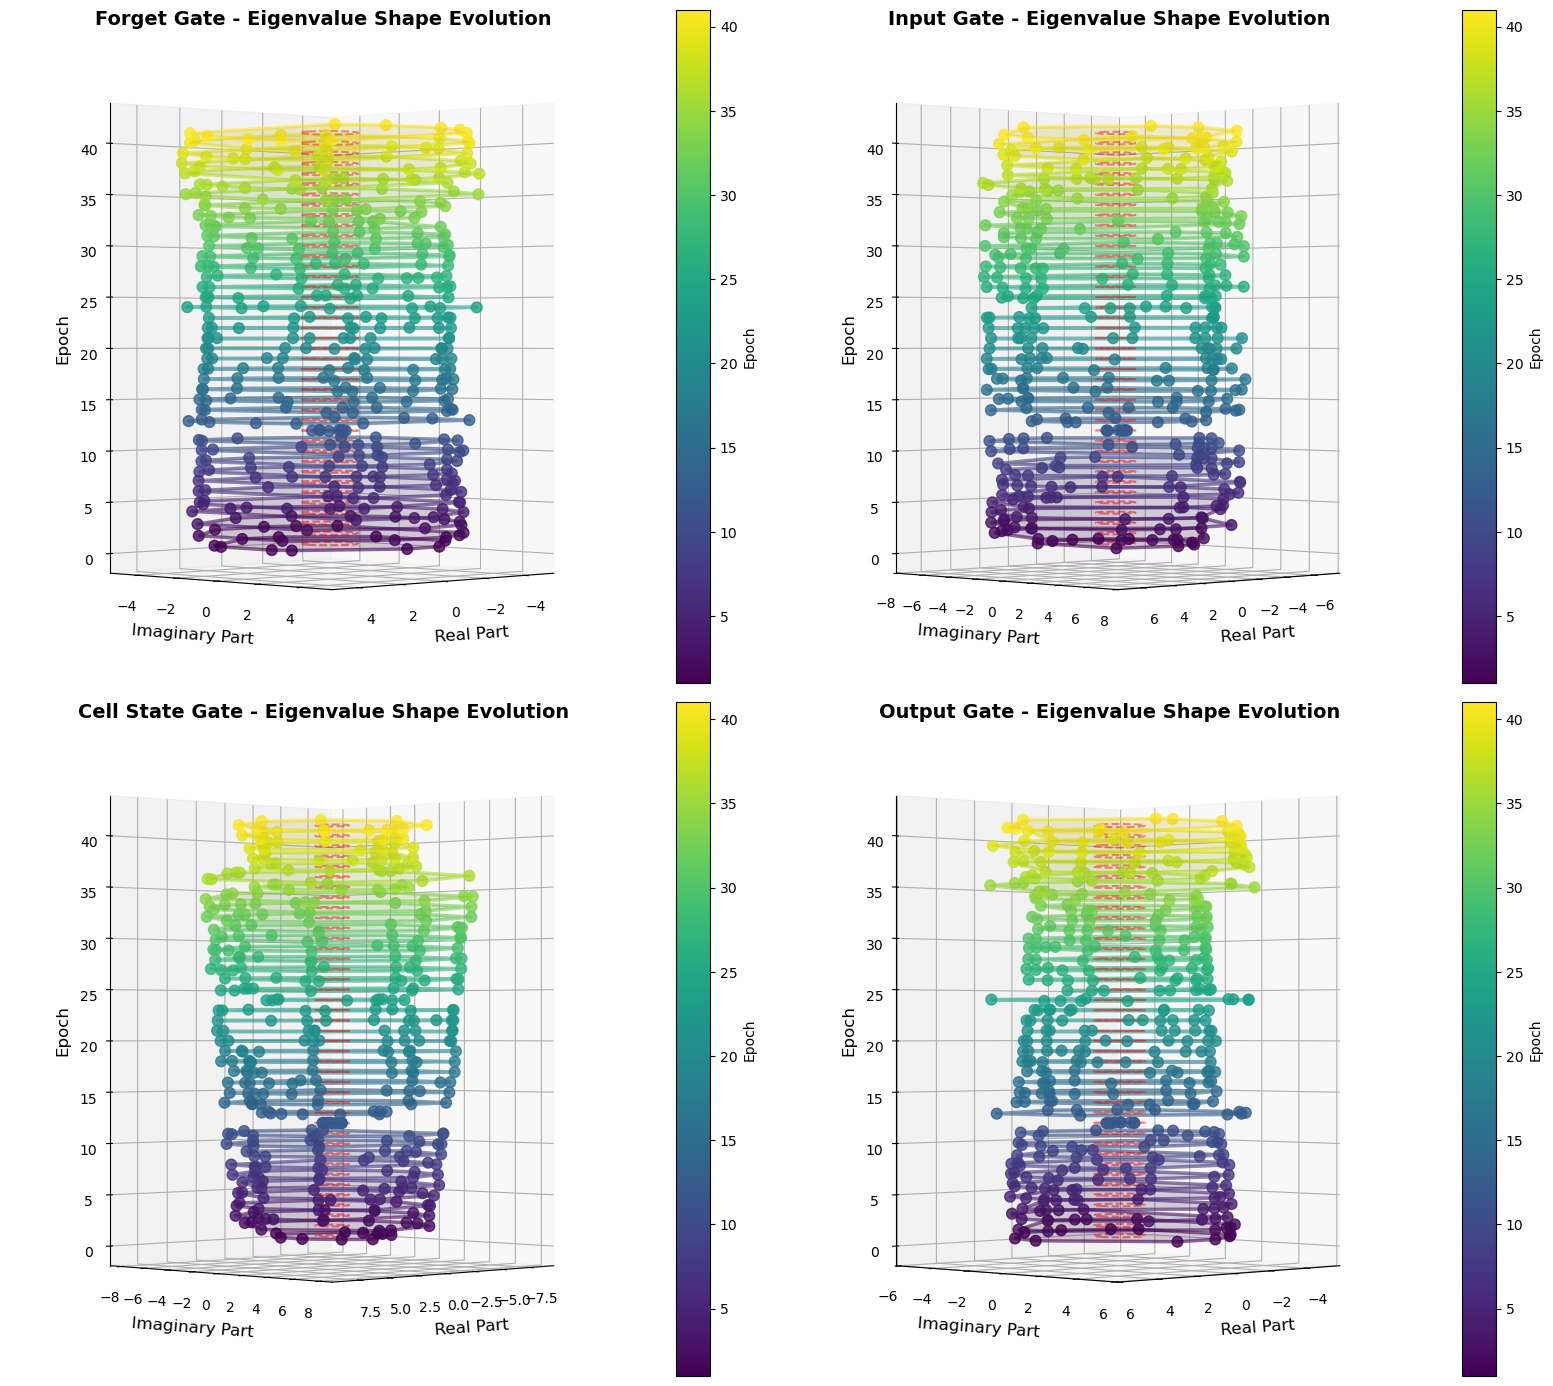

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import ConvexHull
import seaborn as sns
import pandas as pd

def plot_3d_eigenvalue_evolution(eigenvalues_list, gate_names, epochs, figsize=(16, 14), top_n=10):
    """
    Plot 3D Adrian diagrams with enhanced visualization of eigenvalue shapes at each epoch
    
    Parameters:
    - eigenvalues_list: List of lists of eigenvalues per gate across epochs
    - gate_names: List of gate names
    - epochs: Array of epoch numbers
    - figsize: Figure size
    - top_n: Number of top eigenvalues to plot (selected by magnitude)
    """
    plt.ion()

    num_gates = len(eigenvalues_list)
    
    # Create a figure with 3D subplots
    fig = plt.figure(figsize=figsize)
    
    for gate_idx, gate_name in enumerate(gate_names):
        # Create a 3D subplot
        ax = fig.add_subplot(2, 2, gate_idx + 1, projection='3d')
        
        # Prepare colormap for epochs
        cmap = plt.cm.viridis
        norm = plt.Normalize(min(epochs), max(epochs))
        
        # For each epoch, plot the eigenvalues
        for epoch_idx, epoch in enumerate(epochs):
            eig_vals = eigenvalues_list[gate_idx][epoch_idx]
            
            # Select top_n eigenvalues by magnitude
            magnitudes = np.abs(eig_vals)
            top_indices = np.argsort(magnitudes)[-top_n:]  # Get indices of top_n largest magnitudes
            
            # Select only the top eigenvalues
            top_eig_vals = eig_vals[top_indices]
            
            real_parts = np.real(top_eig_vals)
            imag_parts = np.imag(top_eig_vals)
            # Create a time coordinate for all eigenvalues at this epoch
            time_coords = np.full_like(real_parts, epoch)
            
            # Plot eigenvalues as points in 3D space
            scatter = ax.scatter(
                real_parts, 
                imag_parts, 
                time_coords,
                c=[cmap(norm(epoch))] * len(top_eig_vals),
                alpha=0.8,
                s=60,  # Larger points for better visibility
                label=f'Epoch {epoch}'
            )
            
            # Enhanced visualization of the shape:
            # Method 1: Connect points in order of angle for a clean polygon
            angles = np.angle(top_eig_vals)
            sorted_indices = np.argsort(angles)
            
            # Create arrays for the sorted eigenvalues to make a closed polygon
            sorted_real = real_parts[sorted_indices]
            sorted_imag = imag_parts[sorted_indices]
            
            # Add the first point again to close the loop
            sorted_real = np.append(sorted_real, sorted_real[0])
            sorted_imag = np.append(sorted_imag, sorted_imag[0])
            time_array = np.full_like(sorted_real, epoch)
            
            # Draw the polygon connecting eigenvalues
            ax.plot(
                sorted_real,
                sorted_imag,
                time_array,
                color=cmap(norm(epoch)),
                alpha=0.6,
                linewidth=2.5
            )
            
            # Method 2: Fill the polygon with semi-transparent surface for better shape visualization
            # Only do this if we have at least 3 eigenvalues (required for a polygon)
            if len(top_eig_vals) >= 3:
                # Create a polygon patch
                polygon = np.column_stack((sorted_real[:-1], sorted_imag[:-1]))  # Remove duplicate point
                
                try:
                    # Try to create a convex hull for more stable surface plotting
                    hull = ConvexHull(polygon)
                    # Create a surface using the hull vertices
                    for simplex in hull.simplices:
                        x = polygon[simplex, 0]
                        y = polygon[simplex, 1]
                        z = np.full_like(x, epoch)
                        ax.plot_trisurf(x, y, z, color=cmap(norm(epoch)), alpha=0.5)
                except:
                    # Fall back to simple polygon if convex hull fails
                    ax.plot_trisurf(
                        sorted_real[:-1],  # Exclude the duplicate point
                        sorted_imag[:-1], 
                        np.full_like(sorted_real[:-1], epoch),
                        color=cmap(norm(epoch)), 
                        alpha=0.2
                    )
        
        # Add unit circle at each time step
        theta = np.linspace(0, 2*np.pi, 100)
        for epoch in epochs:
            x = np.cos(theta)
            y = np.sin(theta)
            z = np.full_like(theta, epoch)
            ax.plot(x, y, z, 'r--', alpha=0.5, linewidth=1.5)
        
        # Set labels and title
        ax.set_xlabel('Real Part', fontsize=12)
        ax.set_ylabel('Imaginary Part', fontsize=12)
        ax.set_zlabel('Epoch', fontsize=12)
        ax.set_title(f'{gate_name} - Eigenvalue Shape Evolution', fontsize=14, fontweight='bold')
        
        # Set equal aspect ratio for x and y to ensure circle looks like a circle
        # This makes the curvature more apparent
        ax.set_box_aspect([1, 1, 1.5])
        
        # Add grid for better visualization
        ax.grid(True, alpha=0.3)
        
        # Add a colorbar to indicate epochs
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, label='Epoch')
    
    plt.tight_layout()

    # Enable rotation and view adjustment
    for ax in fig.get_axes():
        if hasattr(ax, 'view_init'):  # Check if it's a 3D axis
            ax.view_init(elev=0, azim=45)  # Set initial viewing angle
        
    return fig



# Use the function with your data
fig = plot_3d_eigenvalue_evolution(layer_1_eig_rec_gates, gate_names, epochs, top_n=10)
plt.show()

/tmp/ipykernel_3253037/442964075.py:233: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



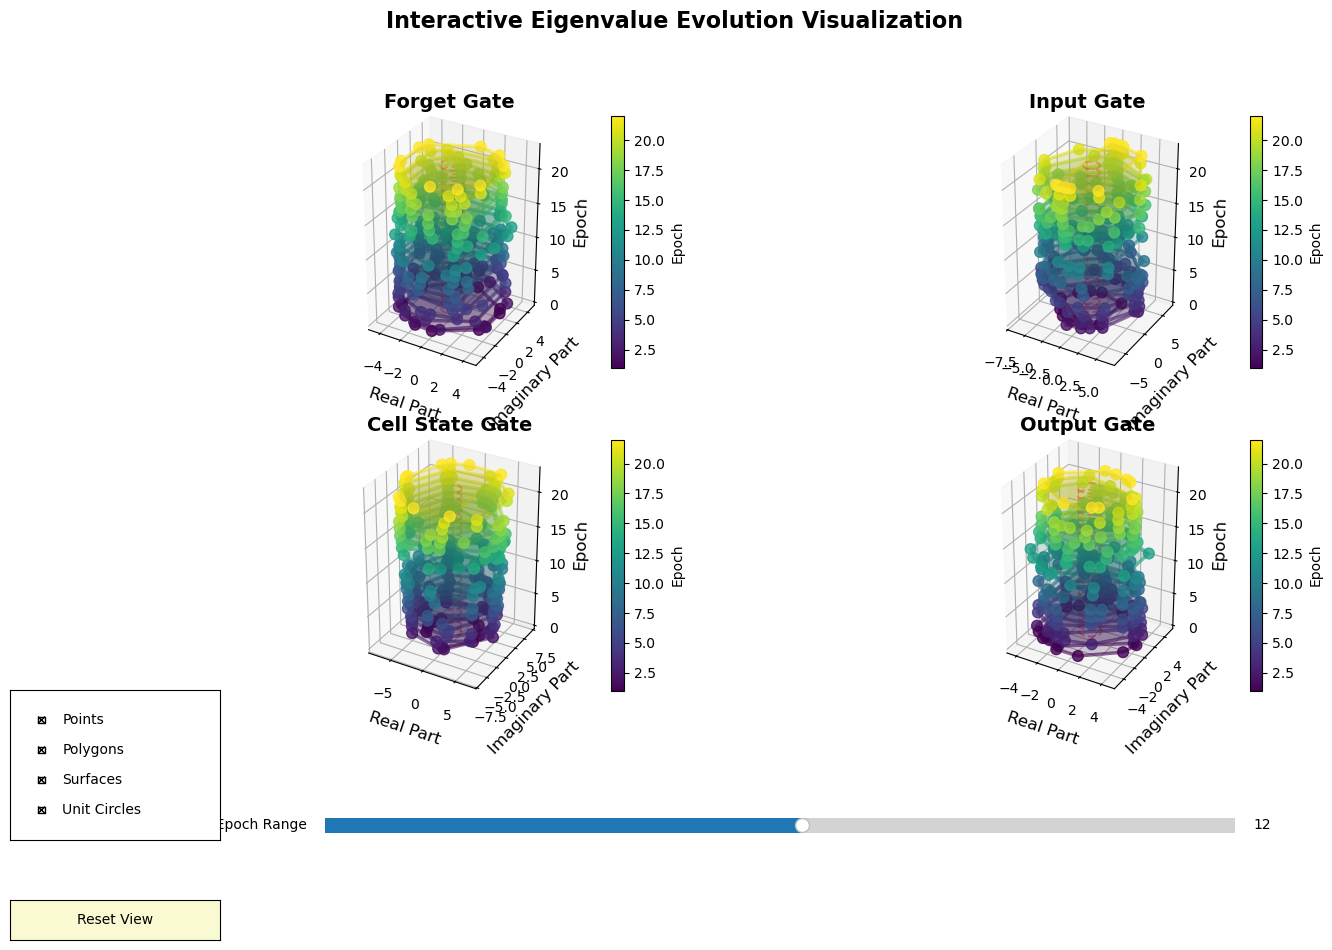

In [216]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.widgets import Slider, Button, CheckButtons
import matplotlib.colors as mcolors
from scipy.spatial import ConvexHull

def plot_interactive_eigenvalues(eigenvalues_list, gate_names, epochs, top_n=10):
    """
    Create an interactive 3D plot of eigenvalue evolution
    
    Parameters:
    - eigenvalues_list: List of lists of eigenvalues per gate across epochs
    - gate_names: List of gate names
    - epochs: Array of epoch numbers
    - top_n: Number of top eigenvalues to plot (selected by magnitude)
    """
    num_gates = len(eigenvalues_list)
    
    # Create figure and subplots
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle('Interactive Eigenvalue Evolution Visualization', fontsize=16, fontweight='bold')
    
    # Create plots
    axes = []
    plots_data = []
    
    # Create a 2x2 grid of subplots for each gate
    for gate_idx, gate_name in enumerate(gate_names):
        # 3D subplot
        ax = fig.add_subplot(2, 2, gate_idx + 1, projection='3d')
        axes.append(ax)
        
        # Store plot data for this gate
        gate_data = {
            'eigenvalues': eigenvalues_list[gate_idx],
            'gate_name': gate_name,
            'points': [],
            'polygons': [],
            'surfaces': [],
            'unit_circles': []
        }
        
        # Prepare colormap
        cmap = plt.cm.viridis
        norm = plt.Normalize(min(epochs), max(epochs))
        
        # For each epoch, process the eigenvalues
        for epoch_idx, epoch in enumerate(epochs):
            eig_vals = eigenvalues_list[gate_idx][epoch_idx]
            
            # Select top_n eigenvalues by magnitude
            magnitudes = np.abs(eig_vals)
            top_indices = np.argsort(magnitudes)[-top_n:]
            top_eig_vals = eig_vals[top_indices]
            
            real_parts = np.real(top_eig_vals)
            imag_parts = np.imag(top_eig_vals)
            time_coords = np.full_like(real_parts, epoch)
            
            # Plot points
            scatter = ax.scatter(
                real_parts, 
                imag_parts, 
                time_coords,
                c=[cmap(norm(epoch))] * len(top_eig_vals),
                alpha=0.8,
                s=60,
                label=f'Epoch {epoch}'
            )
            gate_data['points'].append(scatter)
            
            # Create polygon connecting eigenvalues
            angles = np.angle(top_eig_vals)
            sorted_indices = np.argsort(angles)
            
            sorted_real = real_parts[sorted_indices]
            sorted_imag = imag_parts[sorted_indices]
            
            # Close the loop
            sorted_real = np.append(sorted_real, sorted_real[0])
            sorted_imag = np.append(sorted_imag, sorted_imag[0])
            time_array = np.full_like(sorted_real, epoch)
            
            # Draw polygon lines
            line, = ax.plot(
                sorted_real,
                sorted_imag,
                time_array,
                color=cmap(norm(epoch)),
                alpha=0.6,
                linewidth=2.5
            )
            gate_data['polygons'].append(line)
            
            # Create surface (if enough points)
            surface = None
            if len(top_eig_vals) >= 3:
                try:
                    # Try to create a convex hull
                    polygon = np.column_stack((sorted_real[:-1], sorted_imag[:-1]))
                    hull = ConvexHull(polygon)
                    
                    # Plot surfaces from the hull simplices
                    for simplex in hull.simplices:
                        x = polygon[simplex, 0]
                        y = polygon[simplex, 1]
                        z = np.full_like(x, epoch)
                        surface = ax.plot_trisurf(x, y, z, color=cmap(norm(epoch)), alpha=0.2)
                except:
                    # Fallback
                    surface = ax.plot_trisurf(
                        sorted_real[:-1],
                        sorted_imag[:-1],
                        np.full_like(sorted_real[:-1], epoch),
                        color=cmap(norm(epoch)),
                        alpha=0.2
                    )
            
            if surface:
                gate_data['surfaces'].append(surface)
            
            # Add unit circle
            theta = np.linspace(0, 2*np.pi, 100)
            x = np.cos(theta)
            y = np.sin(theta)
            z = np.full_like(theta, epoch)
            unit_circle, = ax.plot(x, y, z, 'r--', alpha=0.4, linewidth=1.5)
            gate_data['unit_circles'].append(unit_circle)
        
        # Set labels and configure plot
        ax.set_xlabel('Real Part', fontsize=12)
        ax.set_ylabel('Imaginary Part', fontsize=12)
        ax.set_zlabel('Epoch', fontsize=12)
        ax.set_title(f'{gate_name}', fontsize=14, fontweight='bold')
        
        # Set equal aspect ratio for better visualization of curvature
        ax.set_box_aspect([1, 1, 1.5])
        
        # Add grid
        ax.grid(True, alpha=0.3)
        
        # Add colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, label='Epoch')
        
        plots_data.append(gate_data)
    
    # Add interactive controls
    plt.subplots_adjust(bottom=0.25)  # Make room for controls
    
    # Epoch visibility slider
    ax_epoch = plt.axes([0.25, 0.15, 0.65, 0.03])
    epoch_slider = Slider(
        ax=ax_epoch,
        label='Visible Epoch Range',
        valmin=min(epochs),
        valmax=max(epochs),
        valinit=12,#(min(epochs), max(epochs)),
        valfmt='%0.0f',
    )
    
    # Toggle visibility checkboxes
    ax_check = plt.axes([0.025, 0.15, 0.15, 0.15])
    check_labels = ['Points', 'Polygons', 'Surfaces', 'Unit Circles']
    check = CheckButtons(ax_check, check_labels, [True, True, True, True])
    
    # Reset view button
    ax_reset = plt.axes([0.025, 0.05, 0.15, 0.04])
    reset_button = Button(ax_reset, 'Reset View', color='lightgoldenrodyellow', hovercolor='0.975')
    
    # Functions for interactivity
    def update_epoch_visibility(val):
        min_epoch, max_epoch = val
        min_idx = np.argmin(np.abs(epochs - min_epoch))
        max_idx = np.argmin(np.abs(epochs - max_epoch))
        
        for gate_data in plots_data:
            for i, epoch in enumerate(epochs):
                visible = min_epoch <= epoch <= max_epoch
                
                # Update visibility of all plot elements
                if i < len(gate_data['points']):
                    gate_data['points'][i].set_visible(visible)
                if i < len(gate_data['polygons']):
                    gate_data['polygons'][i].set_visible(visible)
                if i < len(gate_data['unit_circles']):
                    gate_data['unit_circles'][i].set_visible(visible)
                
                # Update surfaces if they exist
                if i < len(gate_data['surfaces']):
                    surface = gate_data['surfaces'][i]
                    if hasattr(surface, 'set_visible'):
                        surface.set_visible(visible)
        
        fig.canvas.draw_idle()
    
    def update_visibility(label):
        idx = check_labels.index(label)
        for gate_data in plots_data:
            if idx == 0:  # Points
                for scatter in gate_data['points']:
                    scatter.set_visible(not scatter.get_visible())
            elif idx == 1:  # Polygons
                for line in gate_data['polygons']:
                    line.set_visible(not line.get_visible())
            elif idx == 2:  # Surfaces
                for surface in gate_data['surfaces']:
                    if hasattr(surface, 'set_visible'):
                        surface.set_visible(not surface.get_visible())
            elif idx == 3:  # Unit Circles
                for circle in gate_data['unit_circles']:
                    circle.set_visible(not circle.get_visible())
        
        fig.canvas.draw_idle()
    
    def reset_views(event):
        for ax in axes:
            ax.view_init(elev=30, azim=-60)  # Reset to a good viewing angle
            ax.set_box_aspect([1, 1, 1.5])
        fig.canvas.draw_idle()
    
    # Connect callbacks
    epoch_slider.on_changed(update_epoch_visibility)
    check.on_clicked(update_visibility)
    reset_button.on_clicked(reset_views)
    
    # Set initial view for all subplots
    for ax in axes:
        ax.view_init(elev=30, azim=-60)
    
    plt.tight_layout(rect=[0, 0.25, 1, 0.95])  # Adjust layout to make room for controls
    plt.show()
    
    return fig, plots_data

# Example usage:
fig, data = plot_interactive_eigenvalues(layer_1_eig_rec_gates, gate_names, epochs, top_n=10)

Il faut plutot un plot du cylindre coupé en deux dans la longueur (voir evolution magnitude), et un autre sur les changements de signes.

## First plots

/tmp/ipykernel_3253037/2241699070.py:34: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



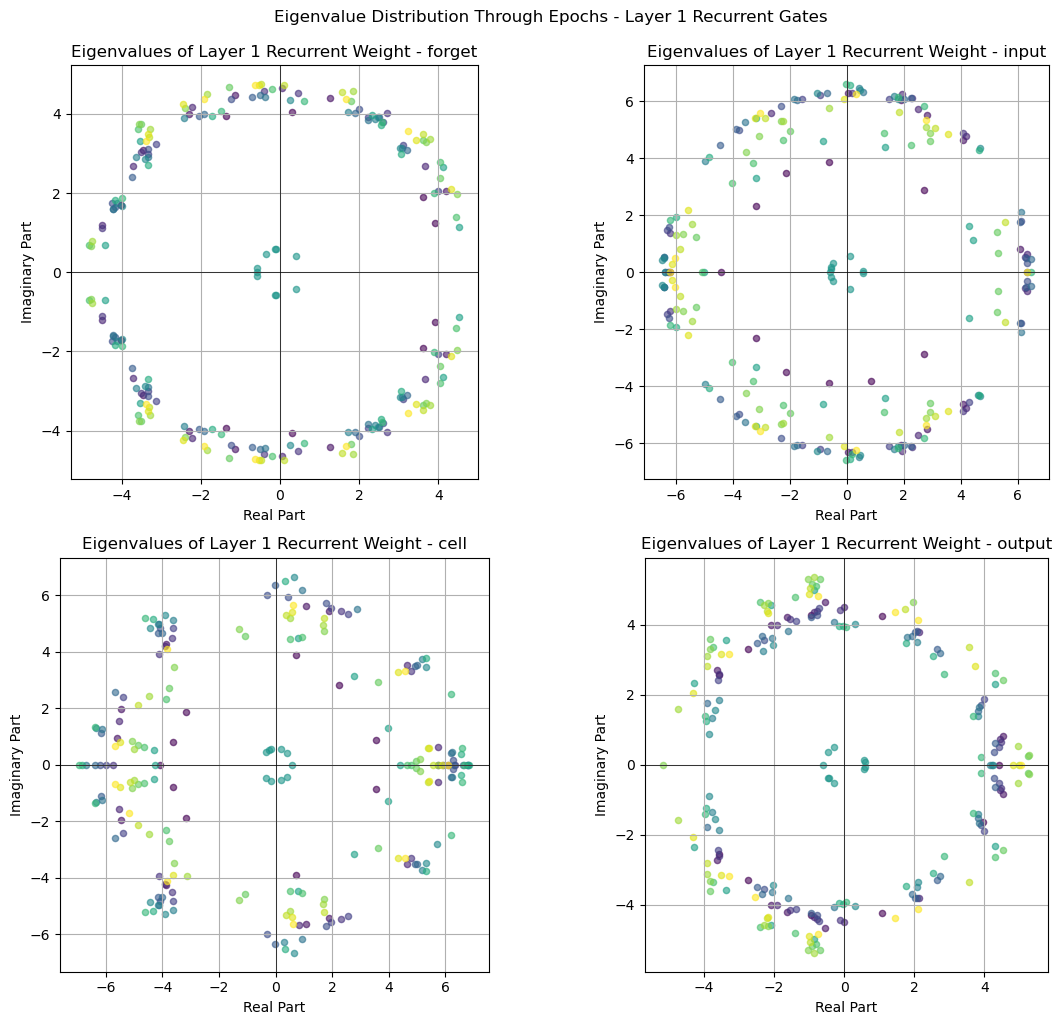

In [147]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

def set_centered_axes(ax):
    """Sets the axes to be centered at (0,0) with equal aspect ratio."""
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_aspect('equal', adjustable='box')



# Assume you have the following variables defined:
# num_gates: the number of recurrent gates
# layer_1_eig_rec_gates: a list where each element corresponds to a gate.
#                        Each element is a list of eigenvalue sets, one for each epoch.
# gate_names: a list of strings, where each string is the name of a gate.
# epochs: a list of epoch numbers.

num_rows = (num_gates + 1) // 2
num_cols = 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows))
axes = axes.flatten() # Flatten the axes array for easy indexing

for i in range(num_gates):
    ax = axes[i]
    gate_eigenvalues_over_epochs = layer_1_eig_rec_gates[i]

    num_epochs = len(gate_eigenvalues_over_epochs)
    cmap = cm.get_cmap('viridis') # You can choose a different colormap
    colors = np.linspace(0, 1, num_epochs)

    for epoch_idx, eig_set in enumerate(gate_eigenvalues_over_epochs):
        eigenvalue_magnitudes = np.abs(eig_set)
        sorted_indices = np.argsort(eigenvalue_magnitudes)[::-1]
        top_10_indices = sorted_indices[:min(10, len(eig_set))]
        top_10_eigenvalues = eig_set[top_10_indices]
        real_parts = np.real(top_10_eigenvalues)
        imag_parts = np.imag(top_10_eigenvalues)
        color = cmap(colors[epoch_idx])
        ax.scatter(real_parts, imag_parts, color=color, alpha=0.6, s=20, label=f'Epoch {epochs[epoch_idx]}')

    ax.set_title(f'Eigenvalues of Layer 1 Recurrent Weight - {gate_names[i]}')
    ax.set_xlabel('Real Part')
    ax.set_ylabel('Imaginary Part')
    ax.grid(True)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal', adjustable='box') # Ensure circular shape
    
    
# Remove any unused subplots if num_gates is odd
if num_gates < num_rows * num_cols:
    for j in range(num_gates, num_rows * num_cols):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Eigenvalue Distribution Through Epochs - Layer 1 Recurrent Gates', y=1.02)
plt.show()

/tmp/ipykernel_3253037/1774123435.py:33: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



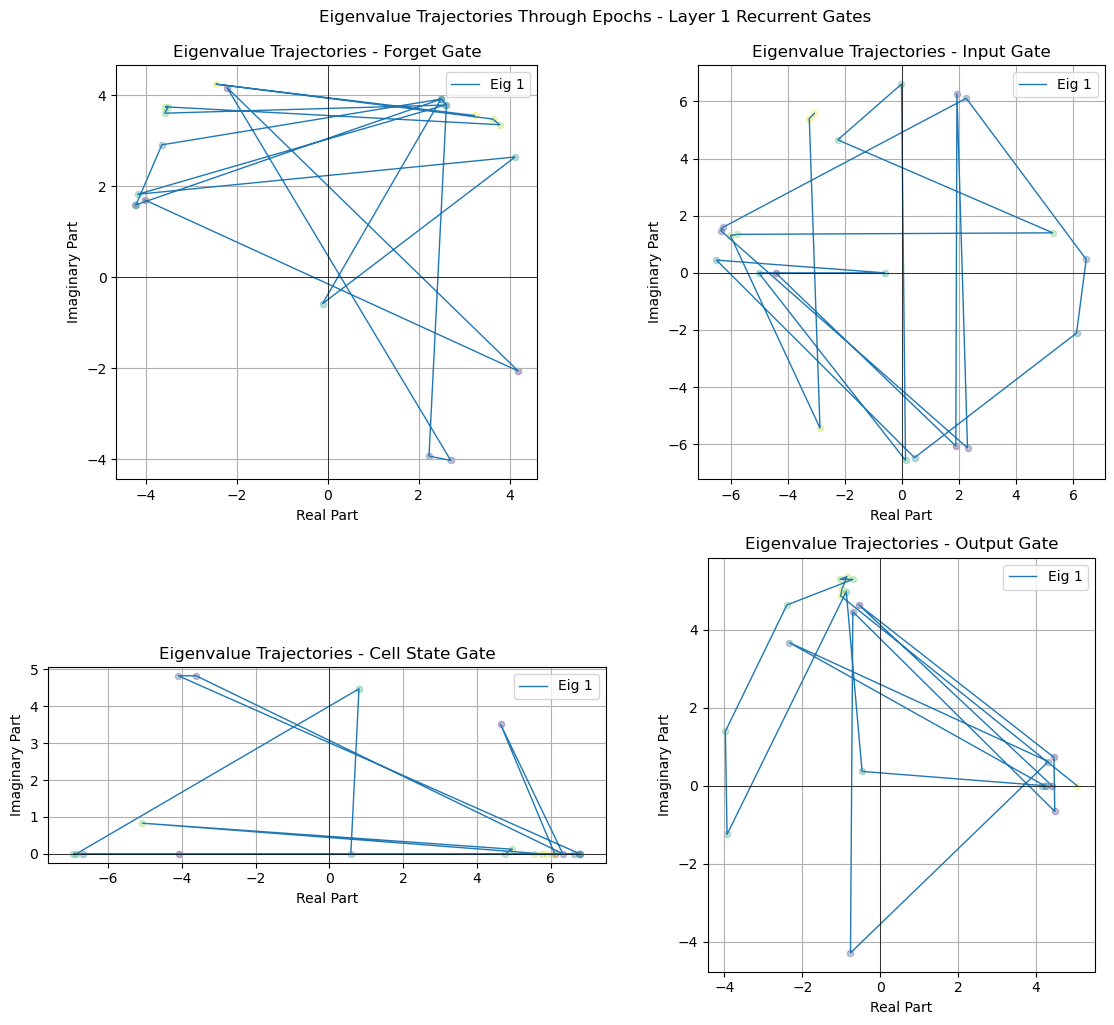

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from matplotlib.lines import Line2D

def set_centered_axes(ax):
    """Sets the axes to be centered at (0,0) with equal aspect ratio."""
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.set_aspect('equal', adjustable='box')

# Assume you have the following variables defined:
# num_gates: the number of recurrent gates
# layer_1_eig_rec_gates: a list where each element corresponds to a gate.
#                        Each element is a list of eigenvalue sets, one for each epoch.
#                        Each eigenvalue set is a numpy array of complex numbers.
# gate_names: a list of strings, where each string is the name of a gate.
# epochs: a list of epoch numbers.

num_rows = (num_gates + 1) // 2
num_cols = 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows))
axes = axes.flatten() # Flatten the axes array for easy indexing

for i in range(num_gates):
    ax = axes[i]
    gate_eigenvalues_over_epochs = layer_1_eig_rec_gates[i]
    num_epochs = len(gate_eigenvalues_over_epochs)
    cmap = cm.get_cmap('viridis')
    colors = np.linspace(0, 1, num_epochs)

    # Store trajectories for the top few eigenvalues
    num_eigenvalues_to_track = min(1, gate_eigenvalues_over_epochs[0].shape[0] if gate_eigenvalues_over_epochs else 0)
    trajectories_real = [[] for _ in range(num_eigenvalues_to_track)]
    trajectories_imag = [[] for _ in range(num_eigenvalues_to_track)]
    trajectory_magnitudes = [[] for _ in range(num_eigenvalues_to_track)]
    trajectory_indices = [None] * num_eigenvalues_to_track # Store original index for consistency

    for epoch_idx, eig_set in enumerate(gate_eigenvalues_over_epochs):
        eigenvalue_magnitudes = np.abs(eig_set)
        sorted_indices = np.argsort(eigenvalue_magnitudes)[::-1]
        top_n_indices = sorted_indices[:num_eigenvalues_to_track]
        top_n_eigenvalues = eig_set[top_n_indices]

        for eig_idx in range(num_eigenvalues_to_track):
            trajectories_real[eig_idx].append(np.real(top_n_eigenvalues[eig_idx]))
            trajectories_imag[eig_idx].append(np.imag(top_n_eigenvalues[eig_idx]))
            trajectory_magnitudes[eig_idx].append(eigenvalue_magnitudes[sorted_indices[eig_idx]])
            if epoch_idx == 0:
                trajectory_indices[eig_idx] = sorted_indices[eig_idx]

        # Scatter plot for all top eigenvalues at the current epoch
        color = cmap(colors[epoch_idx])
        ax.scatter(np.real(top_n_eigenvalues), np.imag(top_n_eigenvalues), color=color, alpha=0.3, s=20)

    # Plot trajectories of the top few eigenvalues
    for j in range(num_eigenvalues_to_track):
        ax.plot(trajectories_real[j], trajectories_imag[j], linestyle='-', linewidth=1, label=f'Eig {j+1}')

    ax.set_title(f'Eigenvalue Trajectories - {gate_names[i]}')
    ax.set_xlabel('Real Part')
    ax.set_ylabel('Imaginary Part')
    ax.grid(True)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='upper right')

# Remove any unused subplots if num_gates is odd
if num_gates < num_rows * num_cols:
    for j in range(num_gates, num_rows * num_cols):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Eigenvalue Trajectories Through Epochs - Layer 1 Recurrent Gates', y=1.02)
plt.show()

## Layer 2

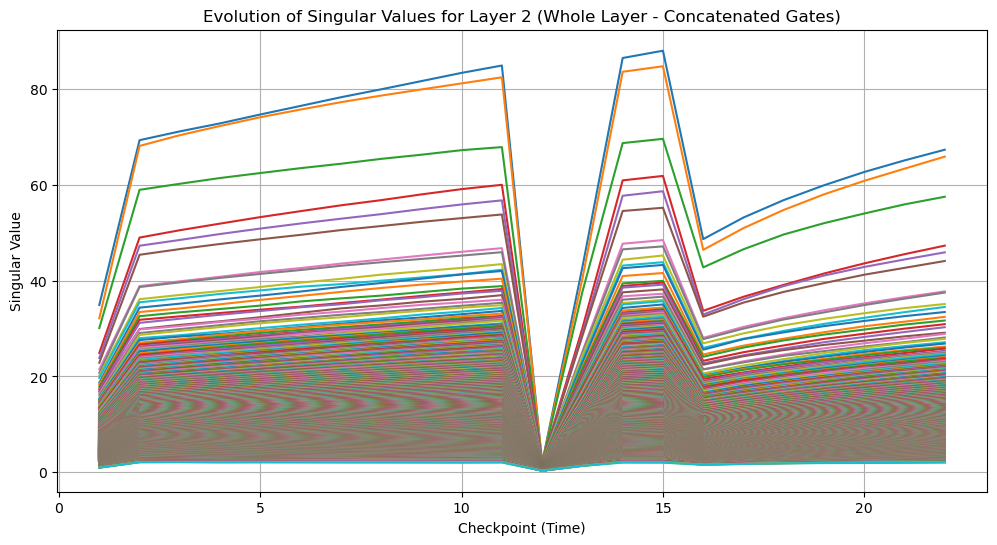

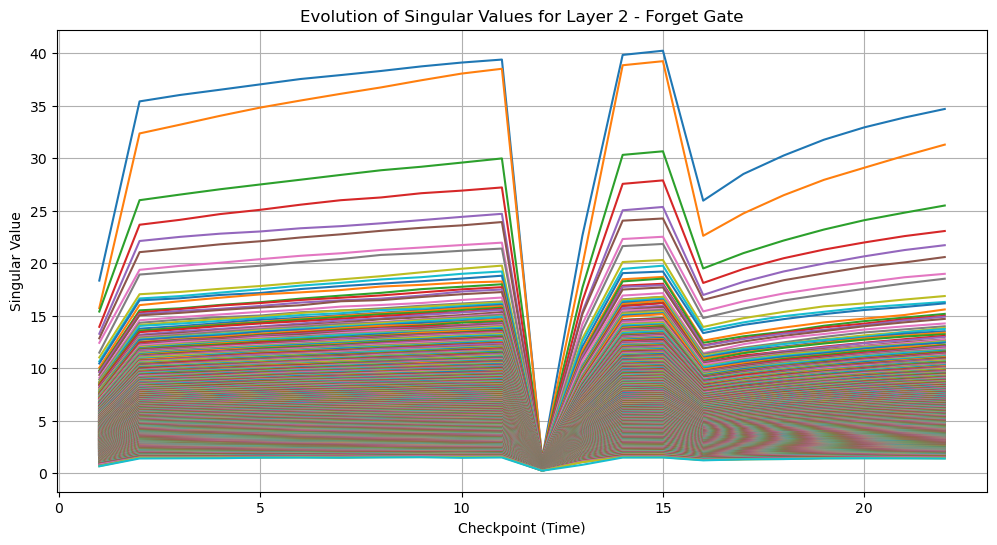

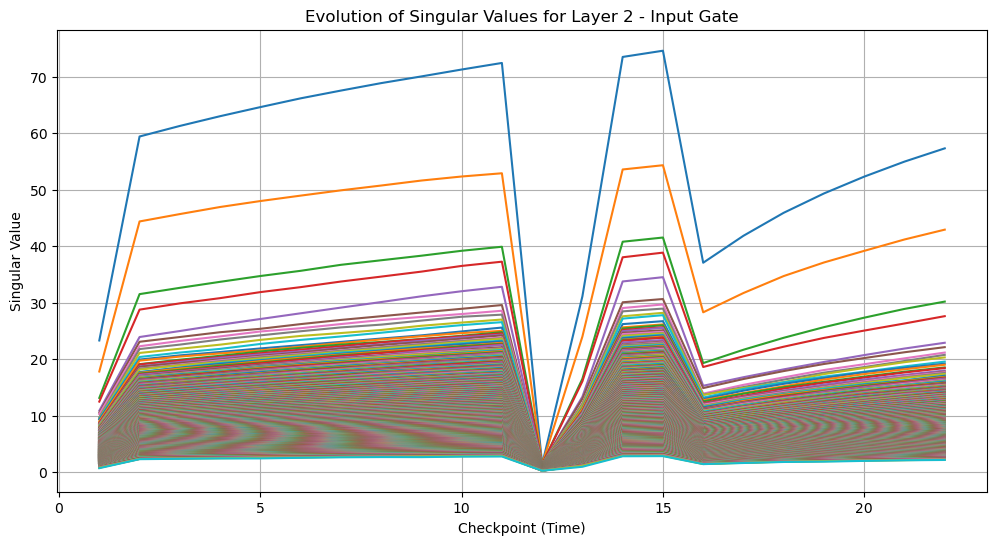

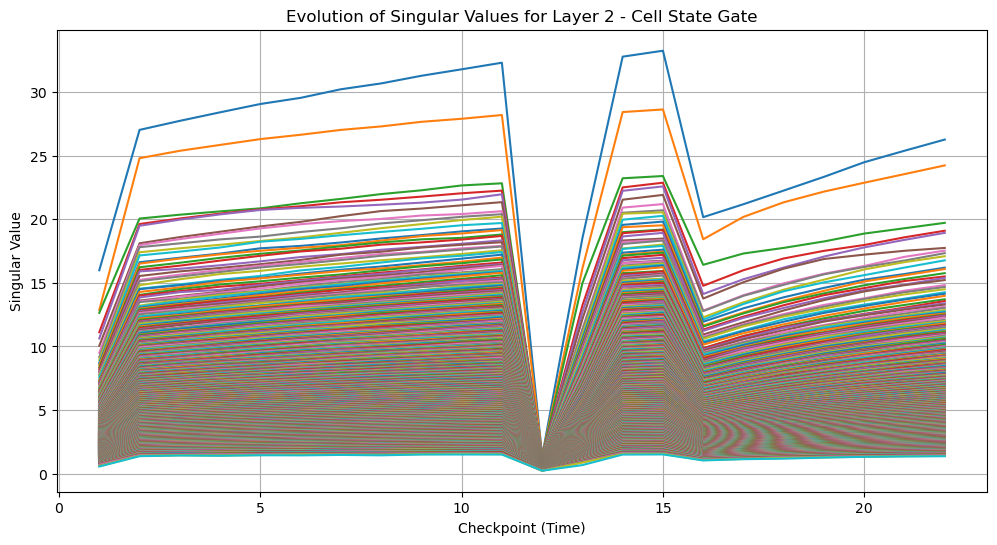

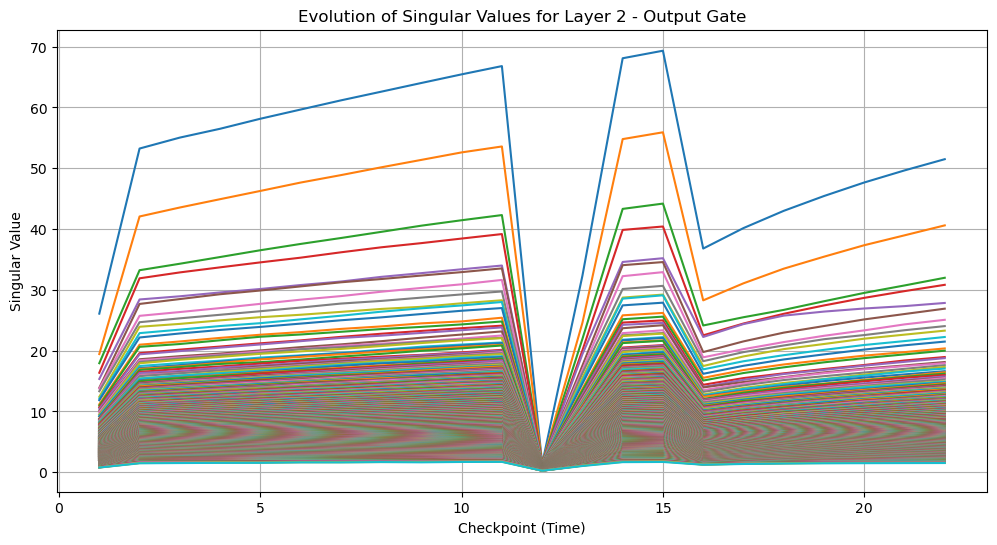

In [23]:
layer2 = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/layer_2_gate_weights_fc.pt')
num_checkpoints = layer2.shape[0]
num_layers = layer2.shape[1]  # Should be 1
num_gates = layer2.shape[2]  # Should be 4
hidden_size = layer2.shape[3]
combined_size = layer2.shape[4]
input_size = combined_size - hidden_size

#Whole layer
layer_2_sv_whole = []
for checkpoint_idx in range(num_checkpoints):
    # Extract weights for all gates at the current checkpoint
    all_gates_weights = layer2[checkpoint_idx, 0]  # Shape: (4, hidden_size, input_size + hidden_size)
    whole_layer_weight = all_gates_weights.reshape(4 * hidden_size, combined_size).numpy()
    sv_whole = np.linalg.svd(whole_layer_weight, compute_uv=False)
    layer_2_sv_whole.append(sv_whole)
plt.figure(figsize=(12, 6))
for i in range(layer_2_sv_whole[0].shape[0]):
    plt.plot(epochs, [s[i] for s in layer_2_sv_whole], label=f'Singular Value {i+1}')
plt.title('Evolution of Singular Values for Layer 2 (Whole Layer - Concatenated Gates)')
plt.xlabel('Checkpoint (Time)')
plt.ylabel('Singular Value')
#plt.legend(fontsize='small')
plt.grid(True)
plt.show()

#By gate
layer_2_sv_gates = [[] for _ in range(num_gates)]
gate_names = ["Forget Gate", "Input Gate", "Cell State Gate", "Output Gate"]
epochs = np.arange(1, num_checkpoints + 1)

for checkpoint_idx in range(num_checkpoints):
    for gate_idx in range(num_gates):
        # Extract the weight matrix for the current gate at the current checkpoint
        gate_weight = layer2[checkpoint_idx, 0, gate_idx].numpy()  # Shape: (hidden_size, combined_size)
        singular_values_gate = np.linalg.svd(gate_weight, compute_uv=False)
        layer_2_sv_gates[gate_idx].append(singular_values_gate)

for i, gate_singular_values in enumerate(layer_2_sv_gates):
    plt.figure(figsize=(12, 6))
    for j in range(gate_singular_values[0].shape[0]):
        plt.plot(epochs, [s[j] for s in gate_singular_values], label=f'Singular Value {j+1}')
    plt.title(f'Evolution of Singular Values for Layer 2 - {gate_names[i]}')
    plt.xlabel('Checkpoint (Time)')
    plt.ylabel('Singular Value')
    #plt.legend(fontsize='small')
    plt.grid(True)
    plt.show()

In [19]:
import torch

# Path to your checkpoint file
checkpoint_path = "/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/lstm_adam/epoch_18.pt"

try:
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

    # Check if the checkpoint contains the optimizer's state_dict
    if 'optimizer_state_dict' in checkpoint:
        optimizer_state = checkpoint['optimizer_state_dict']

        print("Optimizer State Dictionary:")
        for param_group in optimizer_state['param_groups']:
            print(f"\nParameter Group (Learning Rate: {param_group['lr']}):")
            for param_id, state in param_group['state'].items():
                print(f"  Parameter ID: {param_id}")
                for key, value in state.items():
                    print(f"    {key}: {value.shape if isinstance(value, torch.Tensor) else value}")
    else:
        print("The checkpoint does not contain the optimizer's state_dict.")

except FileNotFoundError:
    print(f"Error: Checkpoint file not found at {checkpoint_path}")
except Exception as e:
    print(f"An error occurred: {e}")

The checkpoint does not contain the optimizer's state_dict.


In [20]:
checkpoint

OrderedDict([('encoder.weight',
              tensor([[ 0.0060,  0.1750,  0.2528,  ...,  0.1929, -0.0564, -0.1068],
                      [-0.1153, -0.6737, -0.3251,  ...,  0.3097, -0.2060, -0.1416],
                      [ 0.0918, -0.0074, -0.0121,  ...,  0.0045, -0.4135,  0.0056],
                      ...,
                      [-0.7666, -0.4926, -0.0668,  ..., -0.2296, -0.2341, -0.3069],
                      [ 0.0190, -0.6211,  0.0730,  ..., -0.2605,  0.0955, -0.0381],
                      [-1.0201, -0.5191,  0.0116,  ..., -0.1208, -0.0984,  0.0692]])),
             ('rnn.weight_ih_l0',
              tensor([[-0.0116,  0.0251, -0.0379,  ...,  0.0753, -0.1075,  0.0136],
                      [-0.0531,  0.2455,  0.0873,  ..., -0.0255, -0.0938,  0.0496],
                      [-0.0859, -0.0005,  0.1724,  ..., -0.0545,  0.2970,  0.0543],
                      ...,
                      [ 0.0294, -0.0181,  0.0723,  ...,  0.0194,  0.0011,  0.0113],
                      [-0.2078, -0.02